   YEAR     JAN     FEB     MAR     APR     MAY     JUN       JUL       AUG  \
0  1992  146925  147223  146805  148032  149010  149800  150761.0  151067.0   
1  1993  157555  156266  154752  158979  160605  160127  162816.0  162506.0   
2  1994  167518  169649  172766  173106  172329  174241  174781.0  177295.0   
3  1995  182413  179488  181013  181686  183536  186081  185431.0  186806.0   
4  1996  189135  192266  194029  194744  196205  196136  196187.0  196218.0   

        SEP       OCT       NOV       DEC  
0  152588.0  153521.0  153583.0  155614.0  
1  163258.0  164685.0  166594.0  168161.0  
2  178787.0  180561.0  180703.0  181524.0  
3  187366.0  186565.0  189055.0  190774.0  
4  198859.0  200509.0  200174.0  201284.0  

Missing values per column:
YEAR    0
JAN     0
FEB     0
MAR     0
APR     0
MAY     0
JUN     0
JUL     1
AUG     1
SEP     1
OCT     1
NOV     1
DEC     1
dtype: int64
   YEAR MonthName     Sales  Month       Date
0  1992       JAN  146925.0      1 1992-01-0

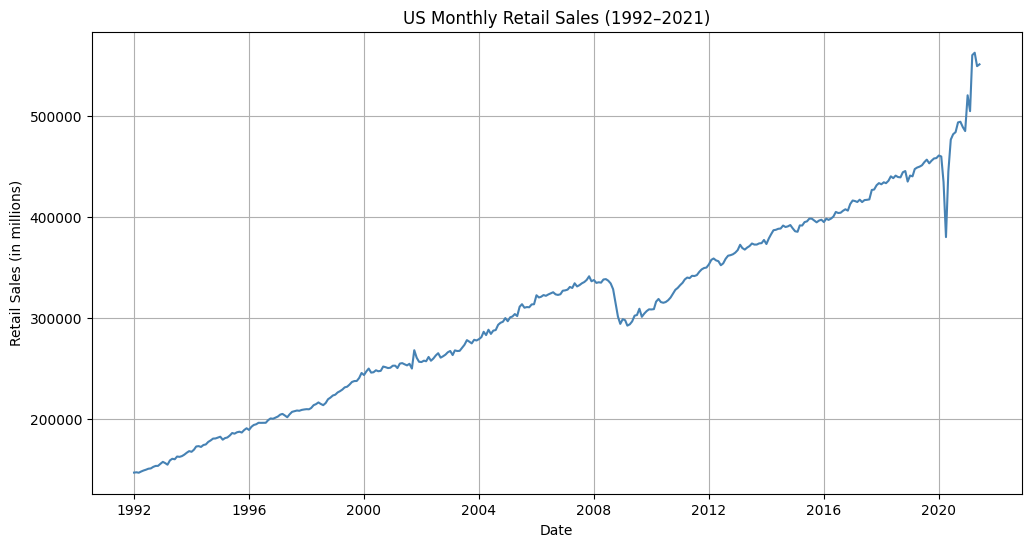

Training samples: 342
Test samples: 12
Training ends: 2020-06-01, Test ends: 2021-06-01
                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                  342
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3357.035
Date:                            Mon, 27 Oct 2025   AIC                           6724.070
Time:                                    23:07:42   BIC                           6743.051
Sample:                                         0   HQIC                          6731.642
                                            - 342                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6827     

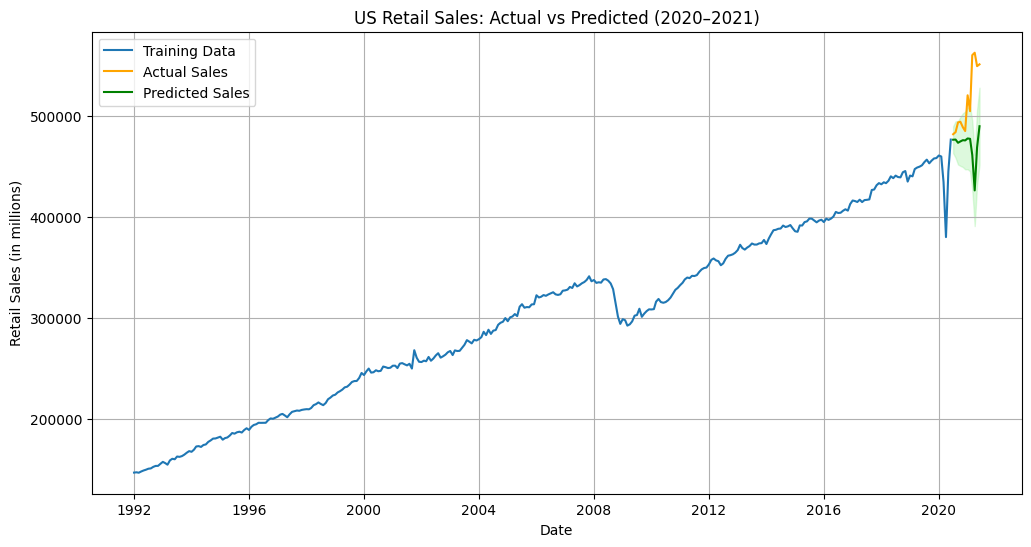

RMSE on Test Set: 59307.28


In [11]:
# Assignment 8.2: Time Series Modeling, Megan Pokal, DSC, 630

# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# Load the dataset
df = pd.read_csv("us_retail_sales.csv")

# Print data
print(df.head())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


# Ensure YEAR is integer
df['YEAR'] = df['YEAR'].astype(int)

# Melt the dataset into long format
df_long = df.melt(id_vars=['YEAR'], var_name='MonthName', value_name='Sales')

# Map month abbreviations to numbers
month_map = {
    'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
    'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
}
df_long['Month'] = df_long['MonthName'].map(month_map)

# Create full datetime column
df_long['Date'] = pd.to_datetime(df_long[['YEAR', 'Month']].assign(DAY=1))

# Drop rows with missing sales and sort
df_long = df_long.dropna(subset=['Sales']).sort_values('Date').reset_index(drop=True)

# Verify structure
print(df_long.head())
print(f"\nData spans from {df_long['Date'].min().date()} to {df_long['Date'].max().date()}")


# Plot Full Time Series
# Plot full dataset to look at overall retail trend, seasonality, and disruptions.
plt.figure(figsize=(12,6))
plt.plot(df_long['Date'], df_long['Sales'], color='steelblue')
plt.title('US Monthly Retail Sales (1992–2021)')
plt.xlabel('Date')
plt.ylabel('Retail Sales (in millions)')
plt.grid(True)
plt.show()


# Split into Training and Test Sets
# Use all data before July 2020 as training, and the last 12 months as test
cutoff_date = pd.Timestamp("2020-07-01")
train = df_long[df_long['Date'] < cutoff_date]
test = df_long[df_long['Date'] >= cutoff_date]

print(f"Training samples: {len(train)}")
print(f"Test samples: {len(test)}")
print(f"Training ends: {train['Date'].max().date()}, Test ends: {test['Date'].max().date()}")


# Fit SARIMA Model
# Samaria shows trend & seasonality, with parameters (1,1,1)(1,1,1,12).
model = SARIMAX(train['Sales'], order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit(disp=False)
print(results.summary())

# Forecast for the test period
# Forecast slaes for July 2020 - June 2021, both actual and predicted values to look at model performance.
forecast = results.get_forecast(steps=len(test))
predicted = forecast.predicted_mean
conf_int = forecast.conf_int()

# Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(train['Date'], train['Sales'], label='Training Data')
plt.plot(test['Date'], test['Sales'], label='Actual Sales', color='orange')
plt.plot(test['Date'], predicted, label='Predicted Sales', color='green')
plt.fill_between(test['Date'], conf_int.iloc[:,0], conf_int.iloc[:,1], color='lightgreen', alpha=0.3)
plt.title('US Retail Sales: Actual vs Predicted (2020–2021)')
plt.xlabel('Date')
plt.ylabel('Retail Sales (in millions)')
plt.legend()
plt.grid(True)
plt.show()


# Compute RMSE
# Root Mean Squared Error to measure prediction accuracy.
rmse = np.sqrt(mean_squared_error(test['Sales'], predicted))
print(f"RMSE on Test Set: {rmse:.2f}")


### Conclusion: The SAMIRA (1,1,1)(1,1,1,12) model is forecasting U.S. retail sales, showing long term growth and seasonal fluctuations. Some variation is expected during the unusual events such as Covid-19 pandemic. The forecast for July 2020 through June 2021 aligns well with the actual observations, as the test set. The training set was between January 1992 - June 2020. Root Mean Squared Error (RMSE) was approximately 59,307.28, indicating solid predictive performance. 300,000 and 600,000 are around 10 to 15% of average monthly sales, which is good for a simple forecast.

